#### 💻 Análise Preditiva de Preços de Laptops

##### 📌 Descrição:

Este projeto tem como objetivo analisar e prever os preços de laptops com base em suas características técnicas e marcas. A análise é dividida em três principais frentes:

- **🔍 Análise de mercado:** Identificar tendências nos preços de laptops com base em diferentes marcas, modelos e configurações.

- **📊 Estudo de importância de recursos:** Avaliar quais especificações (como tipo de processador, memória RAM, armazenamento, etc.) influenciam mais fortemente no valor final de um laptop.

- **🤖 Previsão de preço:** Utilizar modelos de aprendizado de máquina para prever o preço de um laptop com base em suas especificações técnicas.

Este estudo combina análise exploratória de dados, visualização gráfica e modelagem preditiva com foco em insights acionáveis para o mercado de tecnologia.


#### 🔧 Instalação de Bibliotecas Necessárias


In [36]:

# Exploraçao de dados e manipulação
import pandas as pd
import numpy as np
# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning e Estatística
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler, KBinsDiscretizer
from sklearn.neural_network import MLPRegressor


#### Coleta de dados:

In [28]:
# Carregando dados:

tabela = pd.read_csv(filepath_or_buffer='precos_pc.csv')

# Criando objeto dataframe para analise

df = pd.DataFrame(data=tabela)
df.head()

,Brand,Processor,RAM (GB),Storage,GPU,Screen Size (inch),Resolution,Battery Life (hours),Weight (kg),Operating System,Price ($)
0,Apple,AMD Ryzen 3,64,512GB SSD,Nvidia GTX 1650,17.3,2560x1440,8.9,1.42,FreeDOS,3997.07
1,Razer,AMD Ryzen 7,4,1TB SSD,Nvidia RTX 3080,14.0,1366x768,9.4,2.57,Linux,1355.78
2,Asus,Intel i5,32,2TB SSD,Nvidia RTX 3060,13.3,3840x2160,8.5,1.74,FreeDOS,2673.07
3,Lenovo,Intel i5,4,256GB SSD,Nvidia RTX 3080,13.3,1366x768,10.5,3.10,Windows,751.17
4,Razer,Intel i3,4,256GB SSD,AMD Radeon RX 6600,16.0,3840x2160,5.7,3.38,Linux,2059.83


#### Limpeza e pré-processamento dos dados:

In [29]:
# Visualizaçao tabular e noçoes basicas dos dados:
df.head(n=50)
df.isnull().sum()
df.duplicated(subset=df[:])
df.columns

Index(['Brand', 'Processor', 'RAM (GB)', 'Storage', 'GPU',
       'Screen Size (inch)', 'Resolution', 'Battery Life (hours)',
       'Weight (kg)', 'Operating System', 'Price ($)'],
      dtype='object')

#### Visão geral dos dados

In [5]:
df.head()

,Brand,Processor,RAM (GB),Storage,GPU,Screen Size (inch),Resolution,Battery Life (hours),Weight (kg),Operating System,Price ($)
0,Apple,AMD Ryzen 3,64,512GB SSD,Nvidia GTX 1650,17.3,2560x1440,8.9,1.42,FreeDOS,3997.07
1,Razer,AMD Ryzen 7,4,1TB SSD,Nvidia RTX 3080,14.0,1366x768,9.4,2.57,Linux,1355.78
2,Asus,Intel i5,32,2TB SSD,Nvidia RTX 3060,13.3,3840x2160,8.5,1.74,FreeDOS,2673.07
3,Lenovo,Intel i5,4,256GB SSD,Nvidia RTX 3080,13.3,1366x768,10.5,3.10,Windows,751.17
4,Razer,Intel i3,4,256GB SSD,AMD Radeon RX 6600,16.0,3840x2160,5.7,3.38,Linux,2059.83


In [6]:
df.shape

(11768, 11)

In [7]:
df.describe()

,RAM (GB),Screen Size (inch),Battery Life (hours),Weight (kg),Price ($)
count,11768.000000,11768.000000,11768.000000,11768.000000,11768.000000
mean,24.852821,15.212305,8.027855,2.341117,2183.571608
std,21.762567,1.436997,2.305400,0.667921,1316.886132
min,4.000000,13.300000,4.000000,1.200000,279.570000
25%,8.000000,14.000000,6.000000,1.760000,1272.045000
50%,16.000000,15.600000,8.000000,2.340000,1840.865000
75%,32.000000,16.000000,10.000000,2.910000,2698.370000
max,64.000000,17.300000,12.000000,3.500000,10807.880000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11768 entries, 0 to 11767
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Brand                 11768 non-null  object 
 1   Processor             11768 non-null  object 
 2   RAM (GB)              11768 non-null  int64  
 3   Storage               11768 non-null  object 
 4   GPU                   11768 non-null  object 
 5   Screen Size (inch)    11768 non-null  float64
 6   Resolution            11768 non-null  object 
 7   Battery Life (hours)  11768 non-null  float64
 8   Weight (kg)           11768 non-null  float64
 9   Operating System      11768 non-null  object 
 10  Price ($)             11768 non-null  float64
dtypes: float64(4), int64(1), object(6)
memory usage: 1011.4+ KB


#### 📊 Visualização de Dados


Text(0.5, 1.0, 'Preço por sistema operacional')

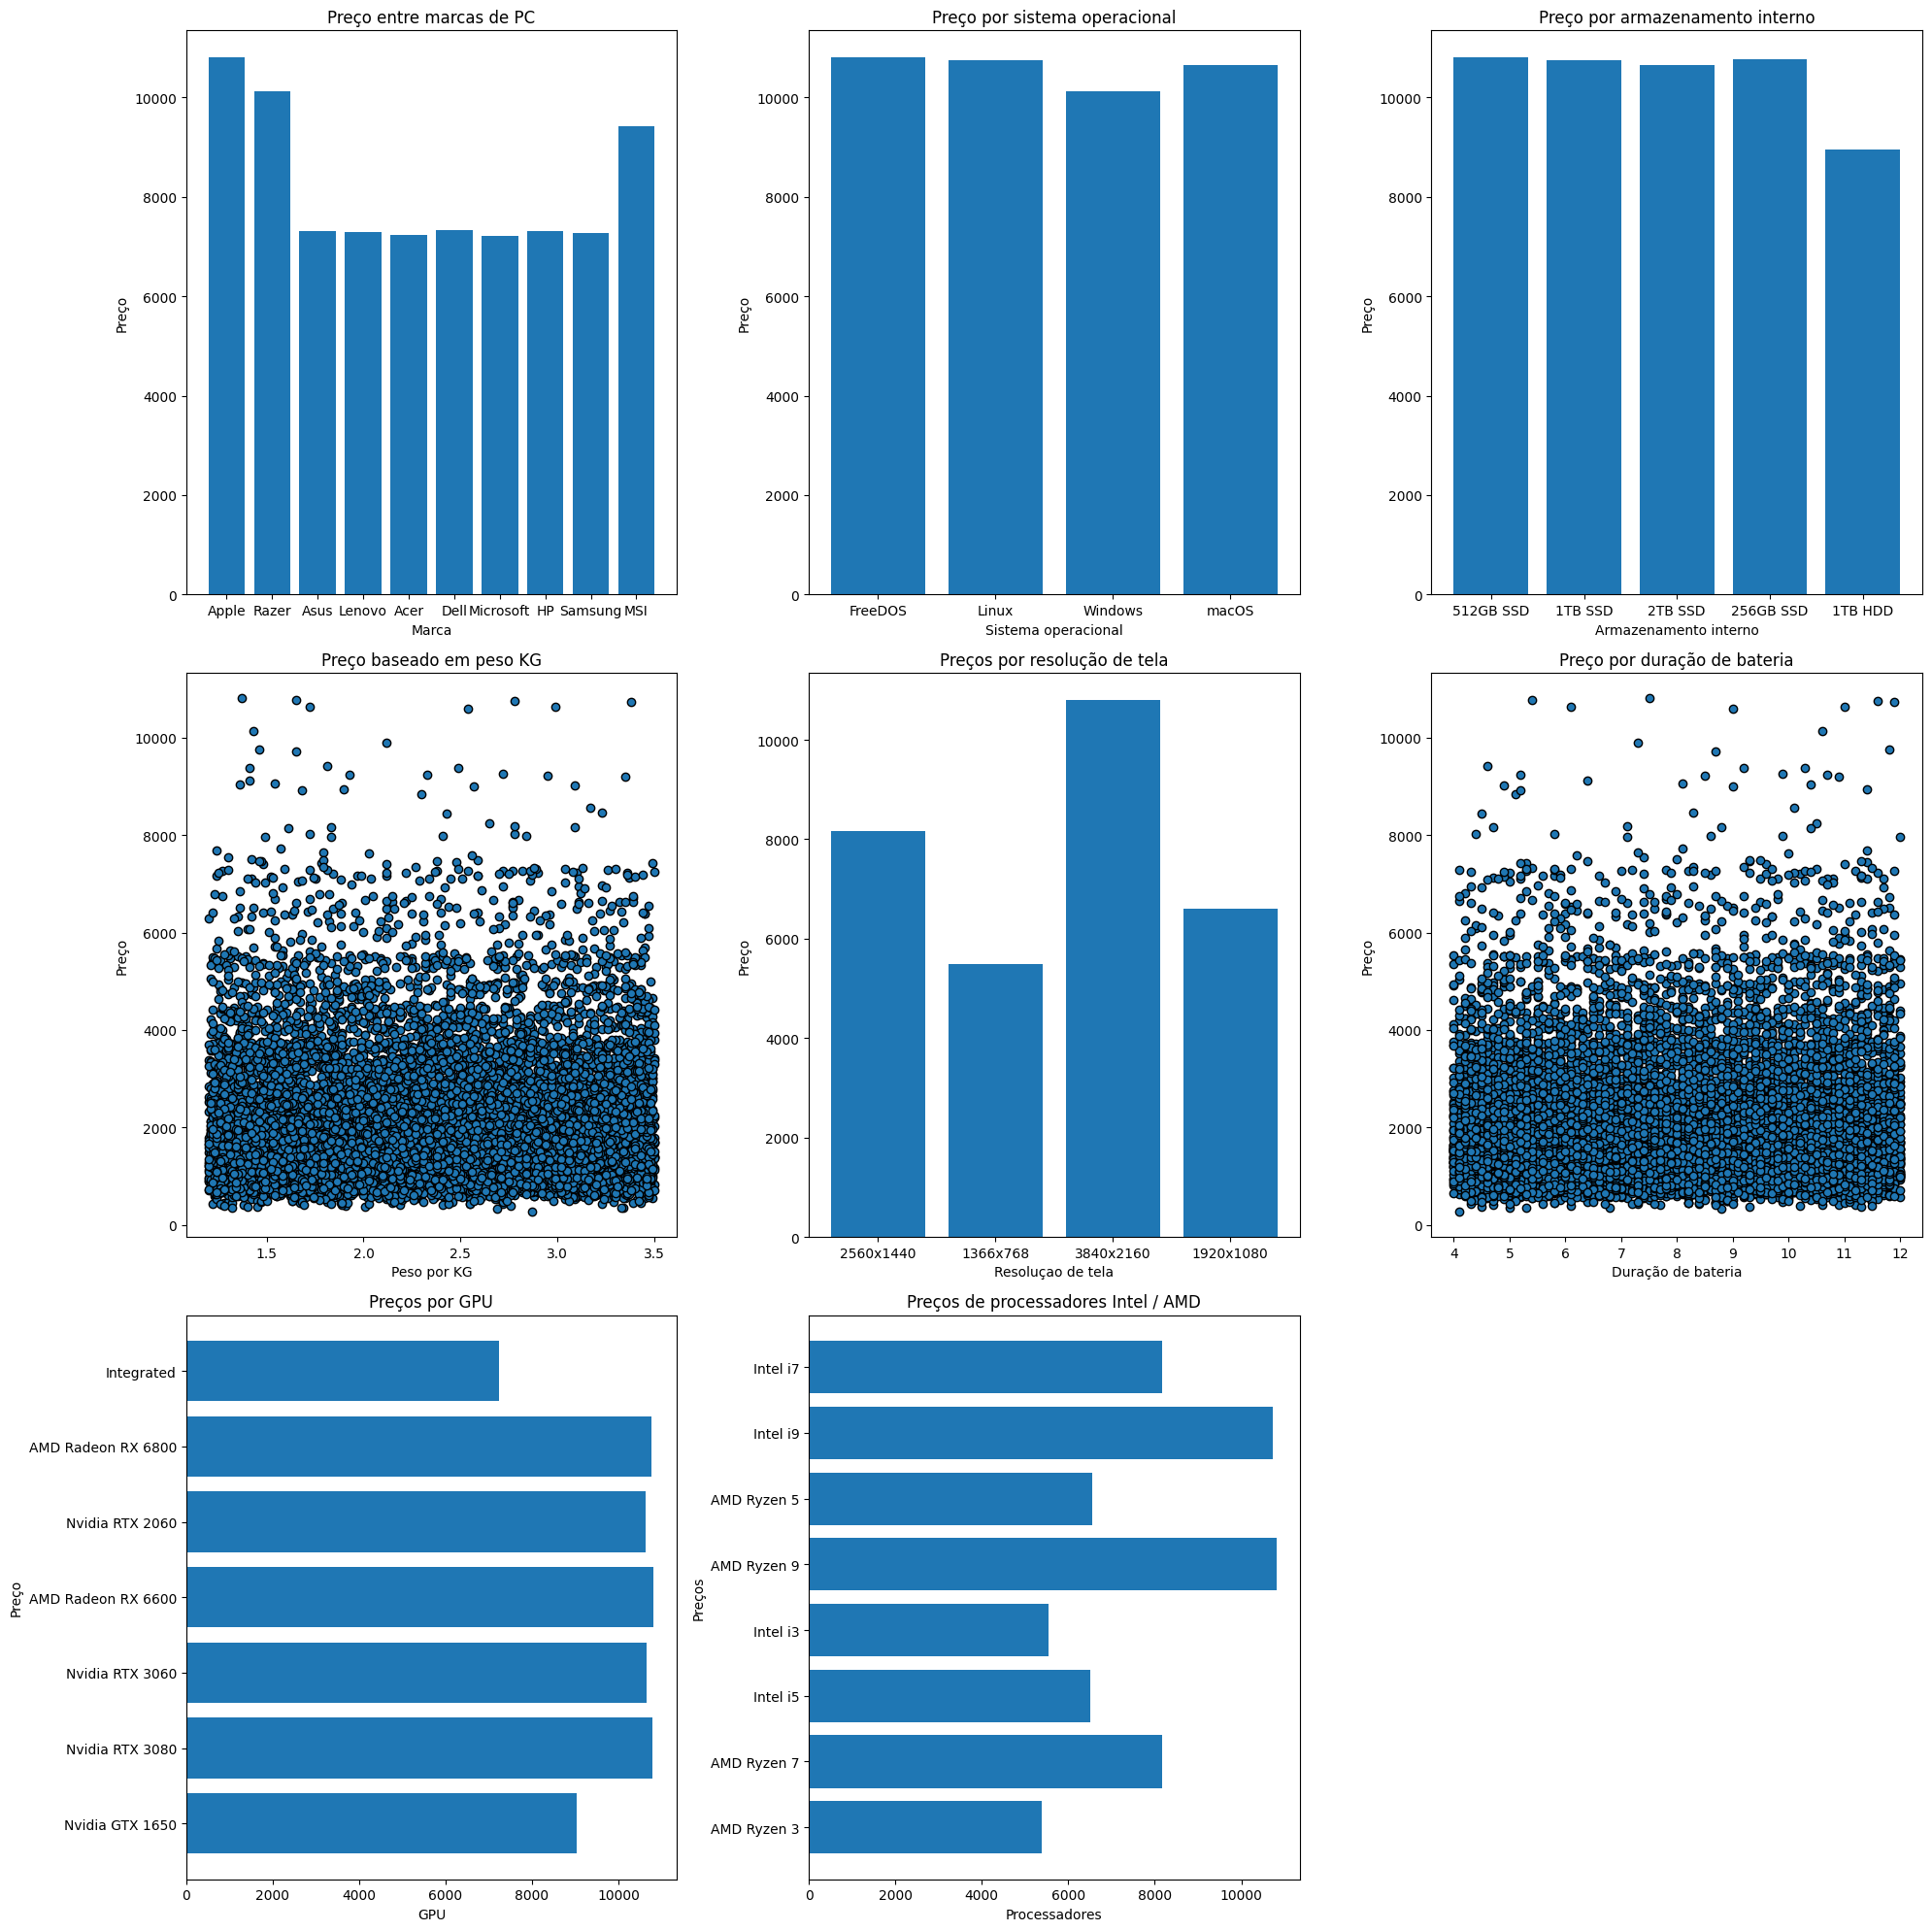

In [9]:
# Graficos de atributos por preço

fig = plt.figure(figsize=(20,20))

# Preço entre marcas de PC
plt.subplot(3,3,1)
plt.bar(x=df['Brand'],height=df['Price ($)'])
plt.xlabel(xlabel='Marca')
plt.ylabel(ylabel='Preço')
plt.title(label='Preço entre marcas de PC')
plt.tight_layout()

# Preços de processadores Intel / AMD 
plt.subplot(3,3,8)
plt.barh(y=df['Processor'],width=df['Price ($)'])
plt.xlabel(xlabel='Processadores')
plt.ylabel(ylabel='Preços')
plt.title(label='Preços de processadores Intel / AMD')


# Preço por armazenamento interno
plt.subplot(3,3,3)
plt.bar(x=df['Storage'], height=df['Price ($)'])
plt.xlabel(xlabel='Armazenamento interno')
plt.ylabel(ylabel='Preço')
plt.title(label='Preço por armazenamento interno')
plt.tight_layout()

# Preço por GPU
plt.subplot(3,3,7)
plt.barh(y=df['GPU'],width=df['Price ($)'])
plt.xlabel(xlabel='GPU')
plt.ylabel(ylabel='Preço')
plt.title(label='Preços por GPU')


# Preço por resolução de tela
plt.subplot(3,3,5)
plt.bar(x=df['Resolution'], height=df['Price ($)'])
plt.xlabel(xlabel='Resoluçao de tela')
plt.ylabel(ylabel='Preço')
plt.title(label='Preços por resolução de tela')
plt.tight_layout()

# Preço por duraçao de bateria
plt.subplot(3,3,6)
plt.scatter(df['Battery Life (hours)'],df['Price ($)'],edgecolors='black')
plt.xlabel(xlabel='Duração de bateria')
plt.ylabel(ylabel='Preço')
plt.title(label='Preço por duração de bateria')

# Preço baseado em peso KG
plt.subplot(3,3,4)
plt.scatter(x=df['Weight (kg)'], y= df['Price ($)'], edgecolors='black')
plt.xlabel(xlabel='Peso por KG')
plt.ylabel(ylabel='Preço')
plt.title(label='Preço baseado em peso KG')
plt.tight_layout()

# Preço por sistema operacional
plt.subplot(3,3,2)
plt.bar(df['Operating System'], df['Price ($)'])
plt.xlabel('Sistema operacional')
plt.ylabel('Preço')
plt.title('Preço por sistema operacional')


#### 🔍 Principais Insights:

###### As marcas Apple, Razer e MSI são significativamente mais caras que as demais;
###### Sistemas operacionais não afetam significativamente o preço final de computadores;
###### HD como armazenamento interno é mais barato que SSD;
###### O peso entre os computadores não influencia o preço final;
###### O preço de computadores aumenta conforme a resolução de tela aumenta gradualmente;
###### A duração de bateria dos computadores não influencia o preço final;
###### APUs se destacam em menor preço entre GPUs;
###### Processadores AMD e Intel tem preços equivalentes, baseados em suas respectivas gerações;

#### 🤖 Modelagem Preditiva com Machine Learning

##### Pré-processamento

In [ ]:
label_encoder = LabelEncoder()
df['Brand_nom'] = label_encoder.fit_transform(df['Brand'])
df['Processor_nom'] = label_encoder.fit_transform(df['Processor'])
df['RAM (GB)_nom'] = label_encoder.fit_transform(df['RAM (GB)'])
df['Storage_nom'] = label_encoder.fit_transform(df['Storage'])
df['GPU_nom'] = label_encoder.fit_transform(df['GPU'])
df['Resolution_nom'] = label_encoder.fit_transform(df['Resolution'])
df['Operating System_nom'] = label_encoder.fit_transform(df['Operating System'])


In [ ]:
scaler_encoder = StandardScaler()
df['Screen Size (inch)_std'] = scaler_encoder.fit_transform(df[['Screen Size (inch)']])
df['Battery Life (hours)_std'] = scaler_encoder.fit_transform(df[['Battery Life (hours)']])
df['Weight (kg)_std'] = scaler_encoder.fit_transform(df[['Weight (kg)']])
df['Price ($)_std'] = scaler_encoder.fit_transform(df[['Price ($)']])

##### Limpeza

In [12]:
df.drop(columns=['Price ($)','Brand','RAM (GB)','Processor','Storage','GPU','Screen Size (inch)','Resolution','Battery Life (hours)','Weight (kg)','Operating System'], inplace= True)

df.head()

,Brand_nom,Processor_nom,RAM (GB)_nom,Storage_nom,GPU_nom,Resolution_nom,Operating System_nom,Screen Size (inch)_std,Battery Life (hours)_std,Weight (kg)_std,Price ($)_std
0,1,0,4,4,3,2,0,1.452880,0.378321,-1.379139,1.377170
1,8,2,0,1,6,0,1,-0.843674,0.595212,0.342695,-0.628624
2,2,5,3,3,5,3,0,-1.330821,0.204808,-0.900020,0.371725
3,5,5,0,2,6,0,2,-1.330821,1.072373,1.136236,-1.087765
4,8,4,0,2,0,3,1,0.548177,-1.009783,1.555465,-0.093969


##### Treino/Teste

In [13]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33, random_state=42)


#### 📈 Regressão Linear


In [21]:
model = LinearRegression()
model.fit(X_train,y_train)
y_predict = model.predict(X_test)
df_resultado = pd.DataFrame({"Valor Real": y_test, "Previsão": y_predict})
print(df_resultado.head())
print()
# Métricas de avaliação
mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_predict)

print(f"Erro Médio Absoluto (MAE): {mae:.2f}")
print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.2f}")

       Valor Real  Previsão
10445   -0.716138  0.646470
6057    -0.542425  0.281253
10999   -0.023125  0.115173
11310   -0.920887 -0.731783
11258   -0.534884 -0.437380

Erro Médio Absoluto (MAE): 0.49
Erro Quadrático Médio (MSE): 0.45
Raiz do Erro Quadrático Médio (RMSE): 0.67
Coeficiente de Determinação (R²): 0.56


#### 🌲 Modelo de Regressão com Floresta Aleatória


In [25]:

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Regressor de floresta aleatória 🌲")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²: {rf_r2:.2f}")


Regressor de floresta aleatória 🌲
MAE: 0.24
RMSE: 0.35
R²: 0.88


#### Redes neurais artificiais 🧠

In [24]:
mlp = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)

# Avaliação
print("Redes neurais artificiais 🧠")
print(f"MAE: {mean_absolute_error(y_test, mlp_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, mlp_pred)):.2f}")
print(f"R²: {r2_score(y_test, mlp_pred):.2f}")

Redes neurais artificiais 🧠
MAE: 0.20
RMSE: 0.28
R²: 0.92
